# Text Chunking, Embedding, and Vector Store Indexing

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from src.embedder import (
    stratified_sample, chunk_dataframe, load_embedding_model,
    embed_chunks, build_chroma_store, CHUNK_SIZE, CHUNK_OVERLAP
)

sns.set_theme(style='whitegrid')
%matplotlib inline

c:\Users\dagic\OneDrive\Documents\KAIM\Week_7\rag-complaint-chatbot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Cleaned Dataset

In [2]:
df = pd.read_csv('../data/processed/filtered_complaints.csv')
print(f'Loaded {len(df):,} records')
print(df['Product'].value_counts())

Loaded 840,334 records
Product
Credit Card        373454
Savings Account    291173
Money Transfer     145066
Personal Loan       30641
Name: count, dtype: int64


In [7]:
df.head(
    3
)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,processed_Issue,clean_length,normalized_feedback,normalized_Issue
0,2025-06-20,Credit Card,General-purpose credit card or charge card,Problem with a company's investigation into an...,Was not notified of investigation status or re...,NaN,NaN,"EQUIFAX, INC.",TX,75104,...,2025-06-20,In progress,Yes,NaN,14196294,9,problem with a companys investigation into an ...,9,problem company investigation exist problem,problem company investigation exist problem
1,2025-06-07,Savings Account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,WELLS FARGO & COMPANY,TX,75034,...,2025-06-09,In progress,Yes,NaN,13984551,3,managing an account,3,manage account,manage account
2,2025-06-07,Savings Account,Checking account,Closing an account,Company closed your account,NaN,NaN,WELLS FARGO & COMPANY,NV,89115,...,2025-06-07,In progress,Yes,NaN,13956296,3,closing an account,3,close account,close account


# Stratified Sample

Sample size: 2,000

Category distribution in sample:
Product
Credit Card        889
Savings Account    693
Money Transfer     345
Personal Loan       73
Name: count, dtype: int64


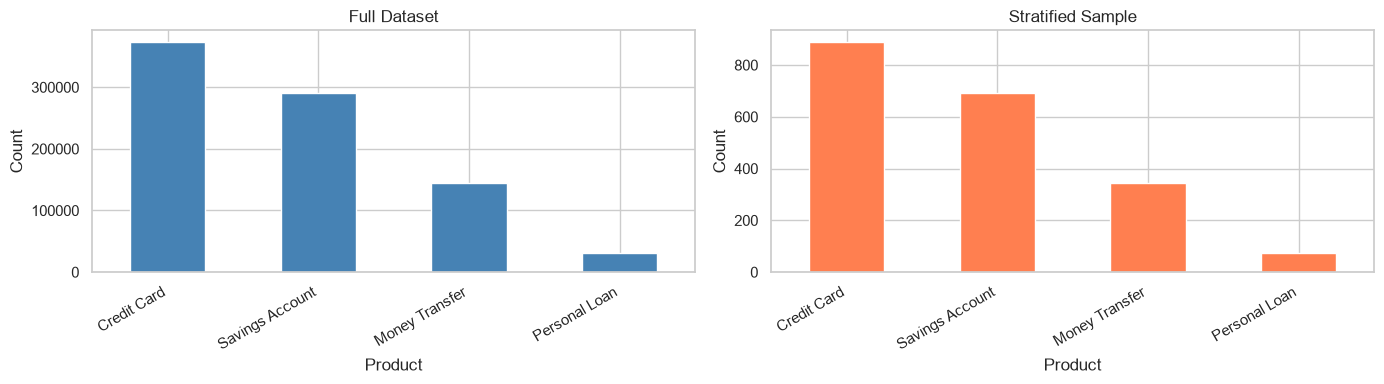

In [5]:
SAMPLE_SIZE = 2000
df_sample = stratified_sample(df, n=SAMPLE_SIZE)
print(f'Sample size: {len(df_sample):,}')
print('\nCategory distribution in sample:')
print(df_sample['Product'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Product'].value_counts().plot(kind='bar', ax=axes[0], title='Full Dataset', color='steelblue')
df_sample['Product'].value_counts().plot(kind='bar', ax=axes[1], title='Stratified Sample', color='coral')
for ax in axes:
    ax.set_xlabel('Product')
    ax.set_ylabel('Count')
    plt.sca(ax)
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/sample_distribution.png', dpi=120)
plt.show()

## Chenk Narrative

In [8]:
print(f'Chunk size: {CHUNK_SIZE} chars | Overlap: {CHUNK_OVERLAP} chars')

chunks = chunk_dataframe(df_sample, text_col='Consumer complaint narrative')
print(f'Total chunks: {len(chunks):,}')
print(f'Avg chunks per complaint: {len(chunks)/len(df_sample):.1f}')

# Chunk length distribution
chunk_lengths = [len(c['text']) for c in chunks]
pd.Series(chunk_lengths).describe()

Chunk size: 500 chars | Overlap: 50 chars
Total chunks: 3,272
Avg chunks per complaint: 1.6


count    3272.000000
mean      366.215465
std       144.854969
min         9.000000
25%       253.000000
50%       421.500000
75%       496.000000
max       500.000000
dtype: float64

In [9]:
# Show a sample chunk with metadata
sample_chunk = chunks[42]
print('Text:')
print(sample_chunk['text'])
print('\nMetadata:')
print(sample_chunk['metadata'])

Text:
these but trust that you will do all that you can in a timely manner.

Metadata:
{'Date received': '2022-05-02', 'Product': 'Money Transfer', 'Sub-product': 'Mobile or digital wallet', 'Issue': 'Unauthorized transactions or other transaction problem', 'Sub-issue': 'nan', 'Company public response': 'nan', 'Company': 'Block, Inc.', 'State': 'TN', 'ZIP code': '37207', 'Tags': 'Servicemember', 'Consumer consent provided?': 'Consent provided', 'Submitted via': 'Web', 'Date sent to company': '2022-05-02', 'Company response to consumer': 'Closed with explanation', 'Timely response?': 'Yes', 'Consumer disputed?': 'nan', 'Complaint ID': '5529313', 'word_count': '6', 'processed_Issue': 'unauthorized transactions or other transaction problem', 'clean_length': '6', 'normalized_feedback': 'unauthorized transaction transaction problem', 'normalized_Issue': 'unauthorized transaction transaction problem', 'chunk_index': 8, 'total_chunks': 10}


## Embed Chunks

In [10]:
print('Loading embedding model: all-MiniLM-L6-v2 ...')
model = load_embedding_model()
print('Model loaded.')

print(f'Embedding {len(chunks):,} chunks ...')
embeddings = embed_chunks(chunks, model, batch_size=128)
print(f'Embedding matrix shape: {embeddings.shape}')

Loading embedding model: all-MiniLM-L6-v2 ...


c:\Users\dagic\OneDrive\Documents\KAIM\Week_7\rag-complaint-chatbot\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dagic\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 

Model loaded.
Embedding 3,272 chunks ...


Batches: 100%|██████████| 26/26 [00:55<00:00,  2.12s/it]

Embedding matrix shape: (3272, 384)


## Build and Persist ChromaDB Store

In [11]:
collection = build_chroma_store(
    chunks=chunks,
    embeddings=embeddings,
    persist_dir='../vector_store/chroma',
)
print(f'Collection count: {collection.count():,} chunks stored')

Collection count: 3,272 chunks stored


## Smoke Test - Semantic Search

In [12]:
from src.embedder import query_store

test_question = 'Why are customers complaining about credit card billing?'
hits = query_store(collection, test_question, model, k=3)

for i, hit in enumerate(hits, 1):
    print(f'--- Hit {i} (distance={hit["distance"]:.4f}) ---')
    print(f'Product: {hit["metadata"].get("product_category")}')
    print(hit['text'][:300])
    print()

--- Hit 1 (distance=0.4131) ---
Product: None
This is a violation of the Fair Credit Billing Act, which gives me the right to raise billing disputes regarding goods or services that were " significantly not as described. '' The denial of my dispute constitutes a violation of this act. I have attached the documentation I sent to Chase for furthe

--- Hit 2 (distance=0.4260) ---
Product: None
billing statement wasn't received or wasn't received in a timely fashion.

--- Hit 3 (distance=0.4514) ---
Product: None
XX/XX/2019 This complaint is for Chase credit card I made a payment to my Chase credit card for {$300.00}, I Called the company to pay the remaining balance around {$800.00} I found out that Chase credit card company cancel the card Then Chase issue me a new card.

